# MUTCD Multimodal RAG — General Notebook

This notebook keeps the original workflow in a clean order:

1. Set up Colab and the repository
2. Load provider keys
3. Check paths and restore the Qdrant database
4. Initialize the pipeline
5. Select one or more models
6. Test the system interactively
7. Load the fixed MUTCD-150 benchmark
8. Run a smoke test
9. Run the full benchmark
10. Check failures, selectively retry, and package outputs

The notebook is **not tied to Gemini, Claude, or Qwen**. Change the
selected aliases in the model-selection cell.

The figure-filter model is always set to `None`. Therefore, the
currently selected answer VLM also performs figure filtering.


## 0. Colab setup and repository update

Skip or modify this section when running outside Colab.


In [1]:
import os
import sys
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules
REPO_DIR = Path("/content/MRAG") if IS_COLAB else Path.cwd()

if IS_COLAB:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    os.environ["MRAG_ENV"] = "colab"

    if not REPO_DIR.exists():
        !git clone https://github.com/hannanazad/MRAG_stp2.git /content/MRAG
    else:
        %cd /content/MRAG
        !git pull

    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))

    # Install the project environment.
    !pip install -q --index-url https://download.pytorch.org/whl/cu124                 torch==2.6.0 torchvision==0.21.0

    !pip install -q -r /content/MRAG/requirements.txt

    !pip install -q --no-deps --force-reinstall                 "transformers>=4.49,<4.55"                 "huggingface_hub>=0.34,<0.35"                 "tokenizers>=0.21,<0.22"                 "torchao>=0.13,<0.14"

    !pip install -q -U openai anthropic

    print(
        "If this cell changed Torch or Transformers, restart the "
        "runtime once before continuing."
    )
else:
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))

    print("Local/HPRC repository:", REPO_DIR)


Mounted at /content/drive
Cloning into '/content/MRAG'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 168 (delta 75), reused 110 (delta 44), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 3.85 MiB | 17.15 MiB/s, done.
Resolving deltas: 100% (75/75), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 104.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 M

## 1. Load provider API keys

Keys only provide access. Model selection is done later.

In Colab, add whichever keys you need under the Secrets panel:

- `DASHSCOPE_API_KEY`
- `ANTHROPIC_API_KEY`
- `GEMINI_API_KEY`


In [2]:
import os

if IS_COLAB:
    from google.colab import userdata

    def load_secret(
        environment_name: str,
        *secret_names: str,
    ) -> None:
        if os.environ.get(environment_name):
            print(environment_name, ": already loaded")
            return

        for secret_name in secret_names:
            try:
                value = userdata.get(secret_name)
            except Exception:
                value = None

            if value:
                os.environ[environment_name] = value
                print(
                    environment_name,
                    f": loaded from {secret_name!r}",
                )
                return

        print(environment_name, ": not loaded")

    load_secret(
        "DASHSCOPE_API_KEY",
        "DASHSCOPE_API_KEY",
        "VLM_API_KEY",
    )
    load_secret(
        "ANTHROPIC_API_KEY",
        "ANTHROPIC_API_KEY",
    )
    load_secret(
        "GEMINI_API_KEY",
        "GEMINI_API_KEY",
    )

if (
    os.environ.get("DASHSCOPE_API_KEY")
    and not os.environ.get("VLM_API_KEY")
):
    os.environ["VLM_API_KEY"] = os.environ[
        "DASHSCOPE_API_KEY"
    ]

print(
    {
        "DashScope": bool(
            os.environ.get("DASHSCOPE_API_KEY")
        ),
        "Anthropic": bool(
            os.environ.get("ANTHROPIC_API_KEY")
        ),
        "Gemini": bool(
            os.environ.get("GEMINI_API_KEY")
        ),
    }
)


DASHSCOPE_API_KEY : not loaded
ANTHROPIC_API_KEY : not loaded
GEMINI_API_KEY : loaded from 'GEMINI_API_KEY'
{'DashScope': False, 'Anthropic': False, 'Gemini': True}


## 2. Environment and path check


In [3]:
import os
import sys

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from mrag.config import CFG

print("Environment :", CFG.environment)
print("Base dir    :", CFG.base_dir)
print("PDF path    :", CFG.pdf_path)
print("Qdrant dir  :", CFG.qdrant_dir)
print("Cache dir   :", CFG.cache_dir)
print("HF cache    :", CFG.hf_home)

assert CFG.pdf_path.exists(), (
    f"No MUTCD PDF was found at {CFG.pdf_path}. "
    f"Place it under {CFG.base_dir}."
)


Environment : colab
Base dir    : /content/drive/MyDrive/MRAG
PDF path    : /content/drive/MyDrive/MRAG/mutcd11theditionr1hl.pdf
Qdrant dir  : /content/qdrant_db
Cache dir   : /content/drive/MyDrive/MRAG/mmrag_cache_v3
HF cache    : /content/drive/MyDrive/MRAG/hf_cache


## 3. Restore or build the Qdrant vector store

If a valid local store exists, it is reused. Otherwise, the Drive
snapshot is restored. If neither exists, ingestion runs once.


In [4]:
import json
import shutil
import tarfile
from pathlib import Path

from qdrant_client import QdrantClient

local_qdrant = Path(CFG.qdrant_dir)
drive_qdrant_tar = (
    Path(CFG.base_dir)
    / "qdrant_db.tar"
)

def qdrant_is_ready(
    path: Path,
) -> bool:
    if not path.exists():
        return False

    try:
        client = QdrantClient(
            path=str(path)
        )
        try:
            names = {
                collection.name
                for collection
                in client.get_collections().collections
            }
            return CFG.coll_chunks in names
        finally:
            client.close()
    except Exception:
        return False

def figure_cache_is_current() -> bool:
    try:
        with Path(CFG.figures_jsonl).open(
            "r",
            encoding="utf-8",
        ) as stream:
            first = json.loads(next(stream))

        return str(
            first.get(
                "extraction_method",
                "",
            )
        ).startswith("caption_below_v2")
    except Exception:
        return False

if (
    qdrant_is_ready(local_qdrant)
    and figure_cache_is_current()
):
    print(
        "Using existing local Qdrant:",
        local_qdrant,
    )

elif (
    drive_qdrant_tar.exists()
    and figure_cache_is_current()
):
    print(
        "Restoring Qdrant snapshot:",
        drive_qdrant_tar,
    )

    shutil.rmtree(
        local_qdrant,
        ignore_errors=True,
    )
    local_qdrant.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with tarfile.open(
        drive_qdrant_tar,
        "r",
    ) as archive:
        archive.extractall(
            local_qdrant.parent
        )

    assert qdrant_is_ready(
        local_qdrant
    )

    print("Qdrant restored.")

else:
    print(
        "No current Qdrant store was found. "
        "Running ingestion."
    )

    if IS_COLAB:
        %cd /content/MRAG
        !python scripts/ingest_v4.py
    else:
        import subprocess
        import sys

        subprocess.run(
            [
                sys.executable,
                str(
                    REPO_DIR
                    / "scripts"
                    / "ingest_v4.py"
                ),
            ],
            cwd=str(REPO_DIR),
            check=True,
        )

    assert qdrant_is_ready(
        local_qdrant
    )
    assert figure_cache_is_current()

    print("Ingestion completed.")


Restoring Qdrant snapshot: /content/drive/MyDrive/MRAG/qdrant_db.tar


/tmp/ipykernel_2939/780539164.py:84: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(


Qdrant restored.


### Optional: save the local Qdrant store back to Drive

Run this after a new ingestion. It is safe to skip when a current
snapshot already exists.


In [ ]:
SAVE_QDRANT_SNAPSHOT = False

if SAVE_QDRANT_SNAPSHOT:
    if CFG.environment != "colab":
        raise RuntimeError(
            "The standard snapshot location is configured for Colab."
        )

    if not local_qdrant.exists():
        raise FileNotFoundError(
            local_qdrant
        )

    drive_qdrant_tar.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        "Saving:",
        local_qdrant,
        "->",
        drive_qdrant_tar,
    )

    with tarfile.open(
        drive_qdrant_tar,
        "w",
    ) as archive:
        archive.add(
            local_qdrant,
            arcname=local_qdrant.name,
        )

    print("Snapshot saved.")
else:
    print("Snapshot cell is disabled.")


## 4. Initialize the pipeline


In [5]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(name)s - %(message)s",
)

from mrag.ask import init_pipeline, ask

pipeline = init_pipeline()

print(
    "VLM:",
    pipeline.vlm.loaded_name
    if pipeline.vlm
    else "not loaded",
)
print(
    "KG:",
    pipeline.kg.g.number_of_nodes(),
    "nodes,",
    pipeline.kg.g.number_of_edges(),
    "edges",
)


/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


VLM: qwen3-vl-plus-2025-12-19
KG: 8240 nodes, 18245 edges


## 5. Select model or models

Edit `SELECTED_MODELS` only.

Use aliases from `CFG.list_vlm_models()` or from the benchmark model
registry.

Examples:

```python
SELECTED_MODELS = {"frontier_qwen"}
SELECTED_MODELS = {"balanced_claude"}
SELECTED_MODELS = {"frontier_gemini", "balanced_gemini", "fast_gemini"}
```

`CFG.set_filter_model(None)` is fixed below. The selected VLM performs
both figure filtering and final answering.


In [6]:
from mrag.config import (
    CFG,
    VLM_API_MODELS,
    provider_of_model,
)

# ---------------------------------------------------------------------------
# Select model or models
# Use a list so the execution order stays predictable.
# ---------------------------------------------------------------------------

SELECTED_MODELS = [
    "balanced_gemini",
]

# Other valid examples:
#
# SELECTED_MODELS = [
#     "frontier_gemini",
# ]
#
# SELECTED_MODELS = [
#     "balanced_gemini",
# ]
#
# SELECTED_MODELS = [
#     "frontier_gemini",
#     "balanced_gemini",
#     "fast_gemini",
# ]

PROMPT_STYLE = "fewshot"

# The selected VLM performs both figure filtering and final answering.
CFG.use_vlm_figure_filter = True
CFG.set_filter_model(None)

MODEL_REGISTRY = []

for model_alias in SELECTED_MODELS:
    if model_alias not in VLM_API_MODELS:
        raise ValueError(
            f"Unknown model alias: {model_alias!r}. "
            "Check CFG.list_vlm_models()."
        )

    resolved_model_id = VLM_API_MODELS[model_alias]
    provider = provider_of_model(resolved_model_id)

    MODEL_REGISTRY.append(
        {
            "alias": model_alias,
            "selector": model_alias,
            "provider": provider,
            "enabled": True,
        }
    )

    print(
        f"{model_alias} -> {resolved_model_id} "
        f"[provider={provider}]"
    )

# Leave the first selected model active for interactive use.
CFG.set_vlm_model(SELECTED_MODELS[0])
CFG.set_filter_model(None)

assert MODEL_REGISTRY, (
    "MODEL_REGISTRY is empty. Check SELECTED_MODELS."
)

print("\nModels supplied to run_benchmark:")
print(MODEL_REGISTRY)

print(
    "\nEffective figure-filter model:",
    CFG.vlm_model_filter or CFG.vlm_model_api,
)

balanced_gemini -> gemini-3.5-flash [provider=gemini]

Models supplied to run_benchmark:
[{'alias': 'balanced_gemini', 'selector': 'balanced_gemini', 'provider': 'gemini', 'enabled': True}]

Effective figure-filter model: gemini-3.5-flash


## 6. Optional interactive questions

Change `RUN_INTERACTIVE_TESTS` to `True` when needed.


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


### Q
Explain Figure 2B-1 and the plaques it shows.

### Answer

Direct Answer: Figure 2B-1 displays the STOP and YIELD signs alongside several associated supplemental plaques. The text specifies that the ALL-WAY plaque is required at all-way stop intersections, while the EXCEPT RIGHT TURN plaque may be used if an engineering study determines it is safe for right-turning traffic to proceed without stopping. 

Standards (mandatory):
- At intersections where all approaches are controlled by STOP signs (see Section 2B.12), an ALL-WAY (R1-3P) supplemental plaque (see Figure 2B-1) shall be mounted below each STOP sign. The ALL-WAY plaque shall have a white legend and border on a red background.

Options (permitted):
- The EXCEPT RIGHT TURN (R1-10P) plaque (see Figure 2B-1) may be mounted below the STOP sign if an engineering study determines that a special combination of geometry and traffic volumes is present that makes it possible for right-turning traffic on the approach to be allowed to enter the intersection without stopping.

Visual evidence:
- [Image 1] presents Figure 2B-1, which illustrates the STOP and YIELD signs as well as several supplemental plaques including ALL WAY and EXCEPT RIGHT TURN.

Citations:
- Section 2B.04 Standard §4 (p.74)
- Section 2B.04 Option §8 (p.74)
- Figure 2B-1 (p.74)

### Figures the model saw

**[Image 1]** Figure 2B-1 (p.74) — depicts R1-1, R1-10P, R1-2, R1-3P, W4-4AP, W4-4BP, W4-4P  
*Figure 2B-1. STOP and YIELD Signs and Plaques*  
score=0.000

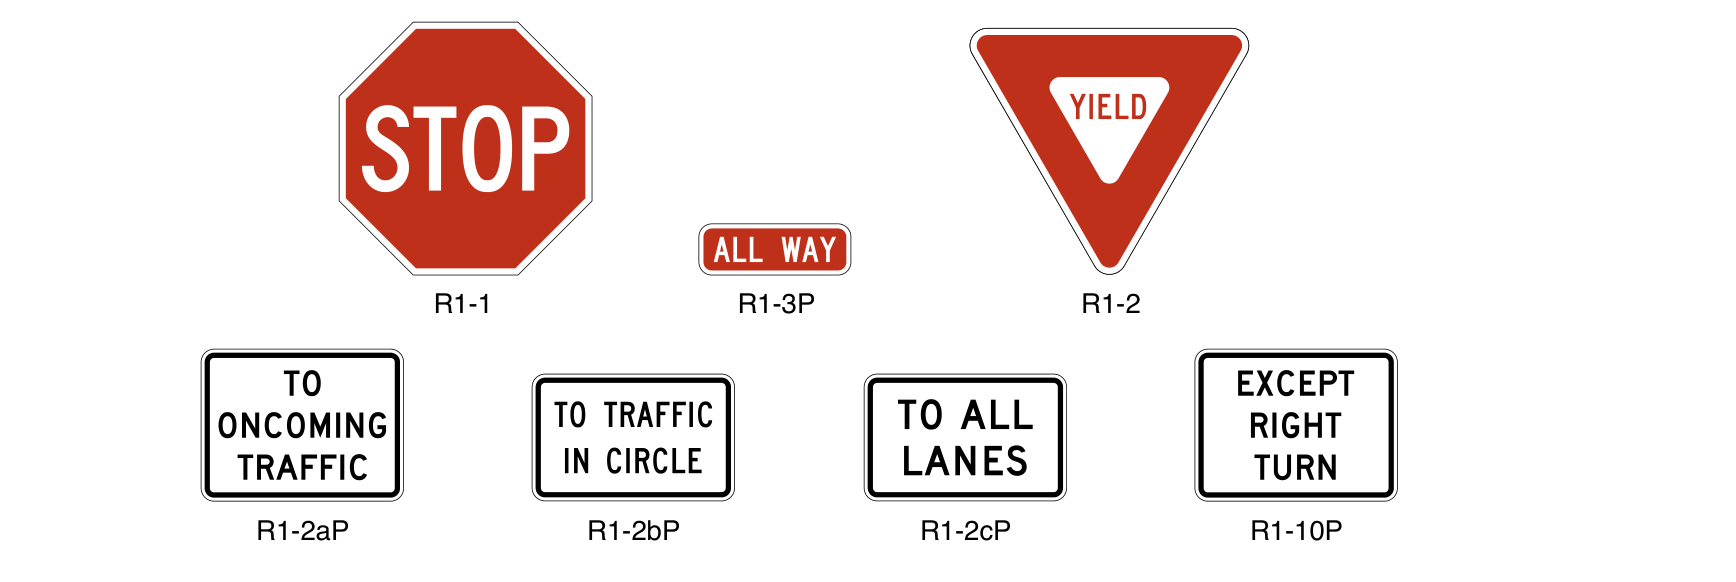

### Pages retrieved by ColPali

**[Page 1]** p.115 (score=15.459)

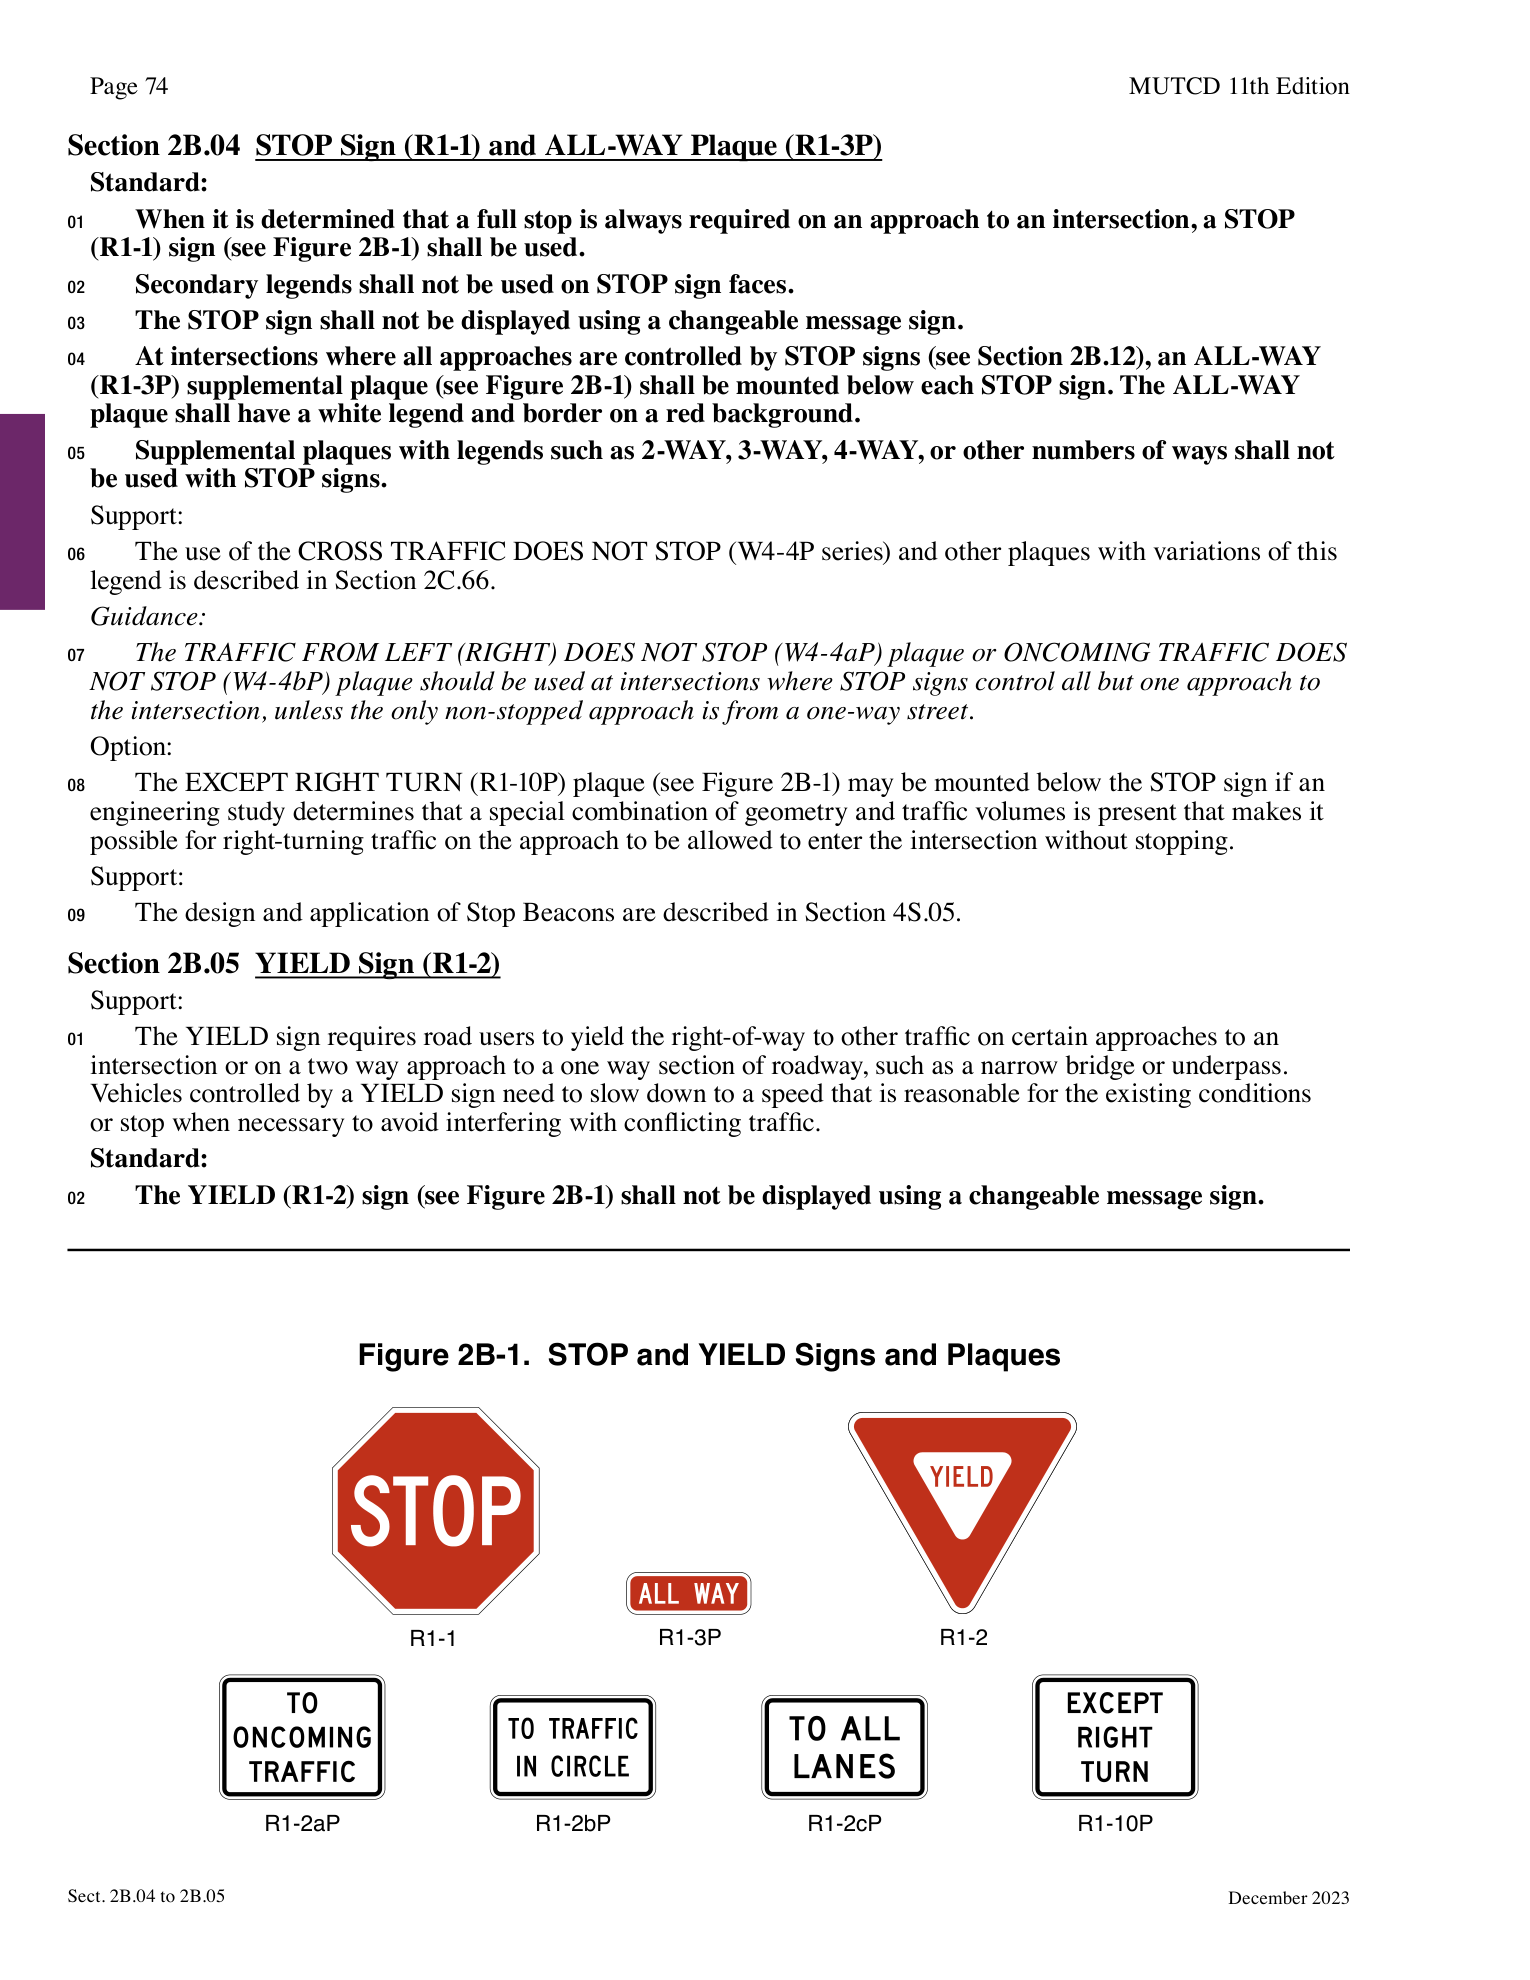

**[Page 2]** p.150 (score=15.158)

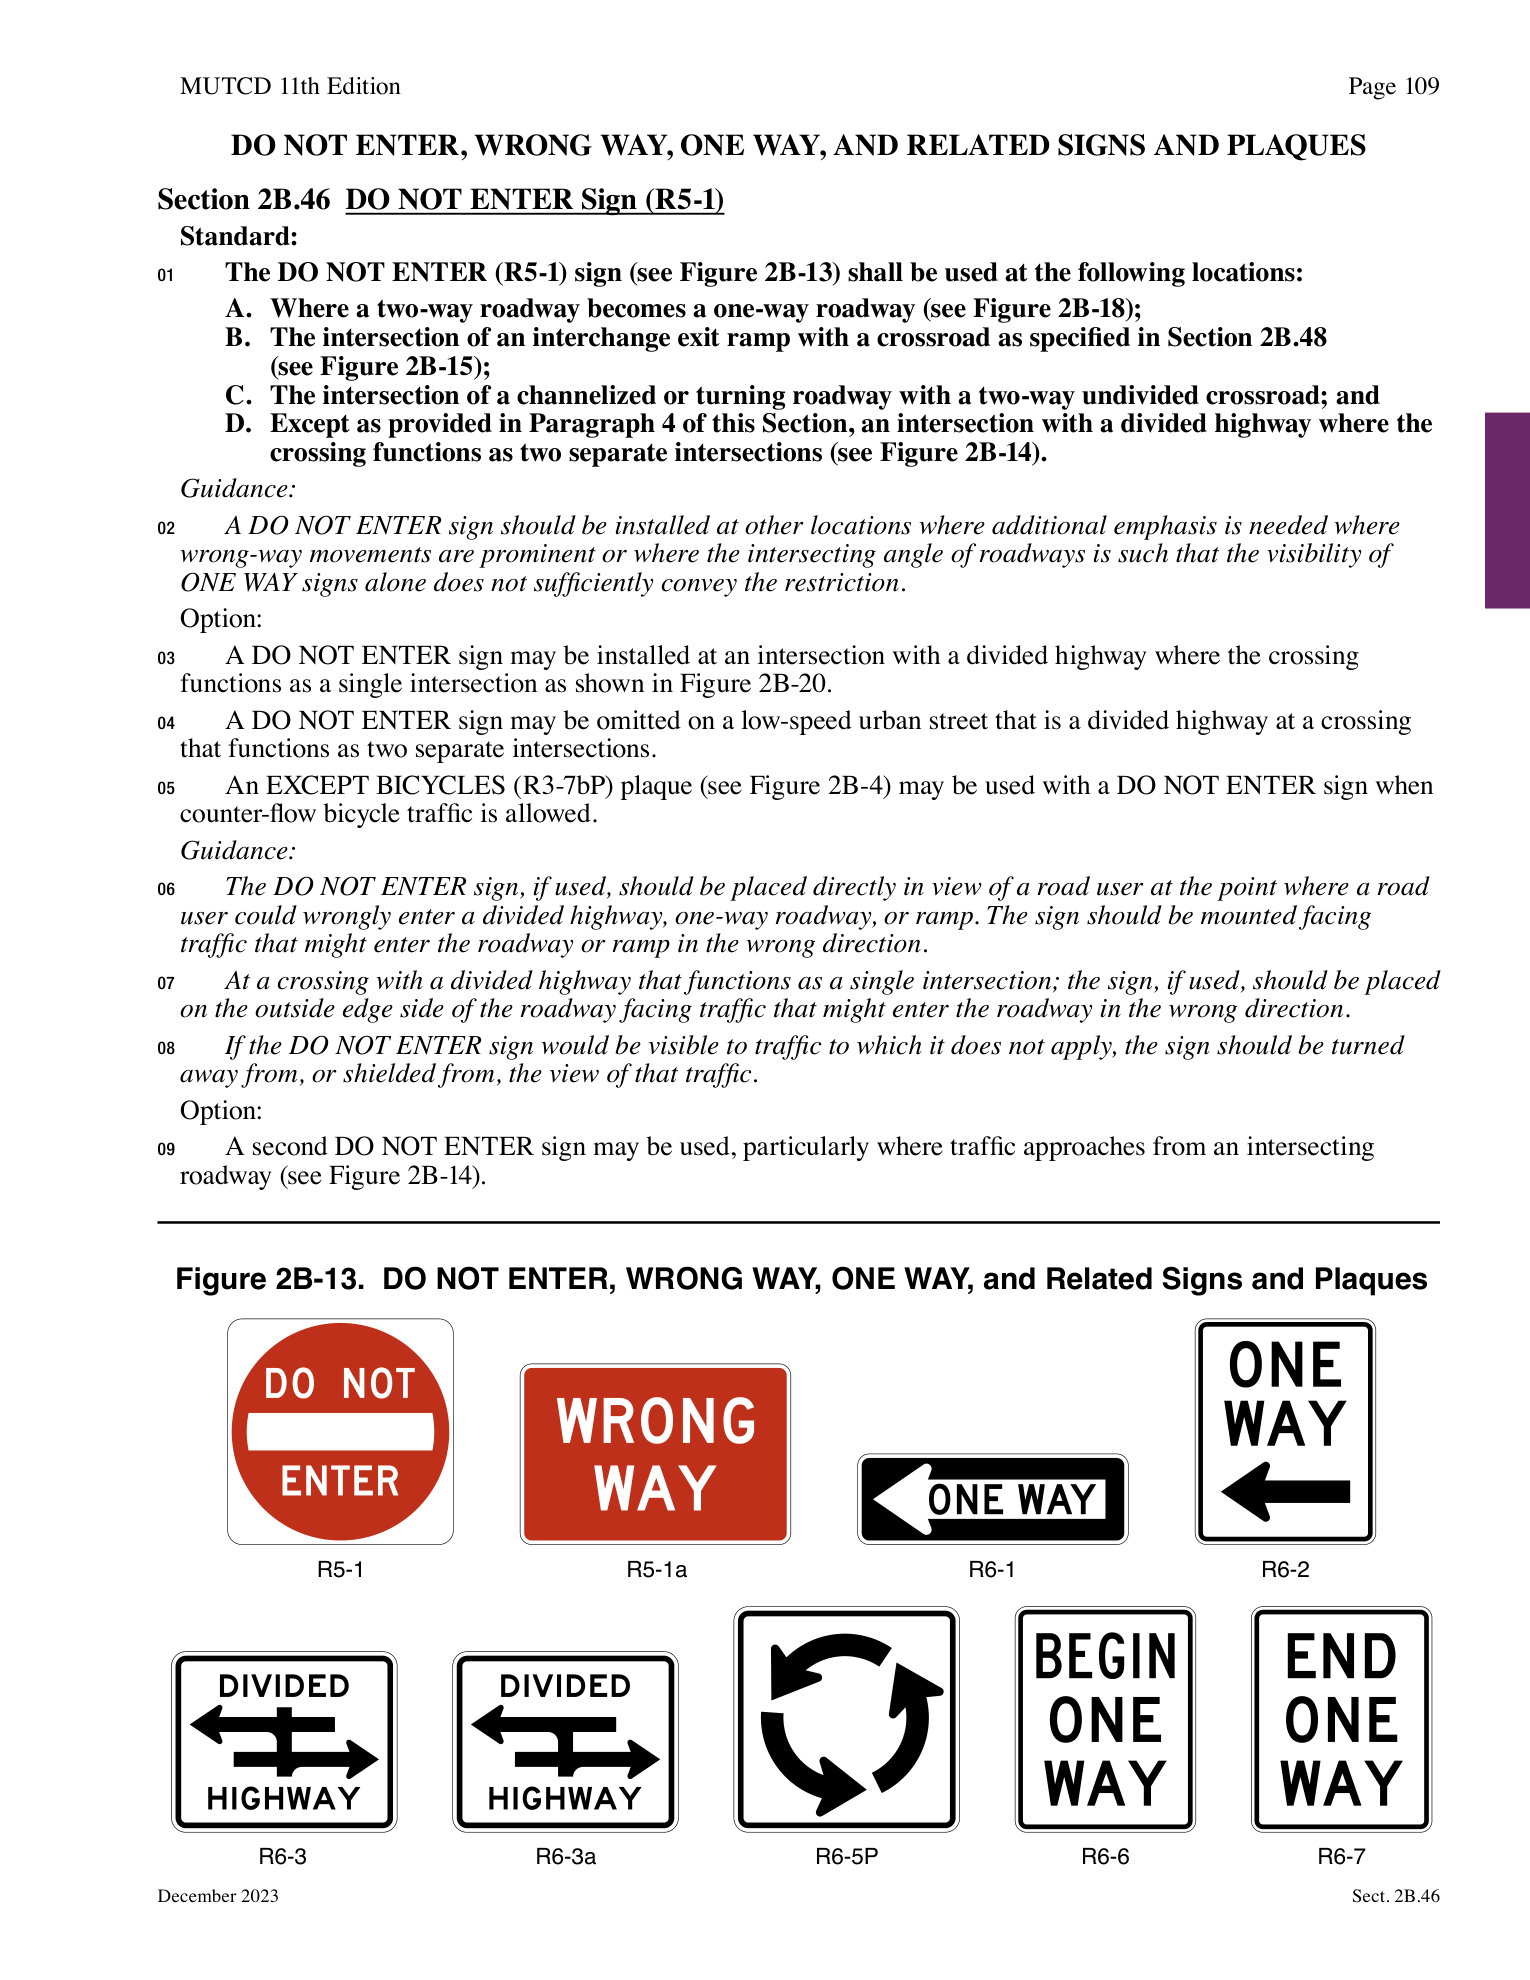

**[Page 3]** p.148 (score=15.115)

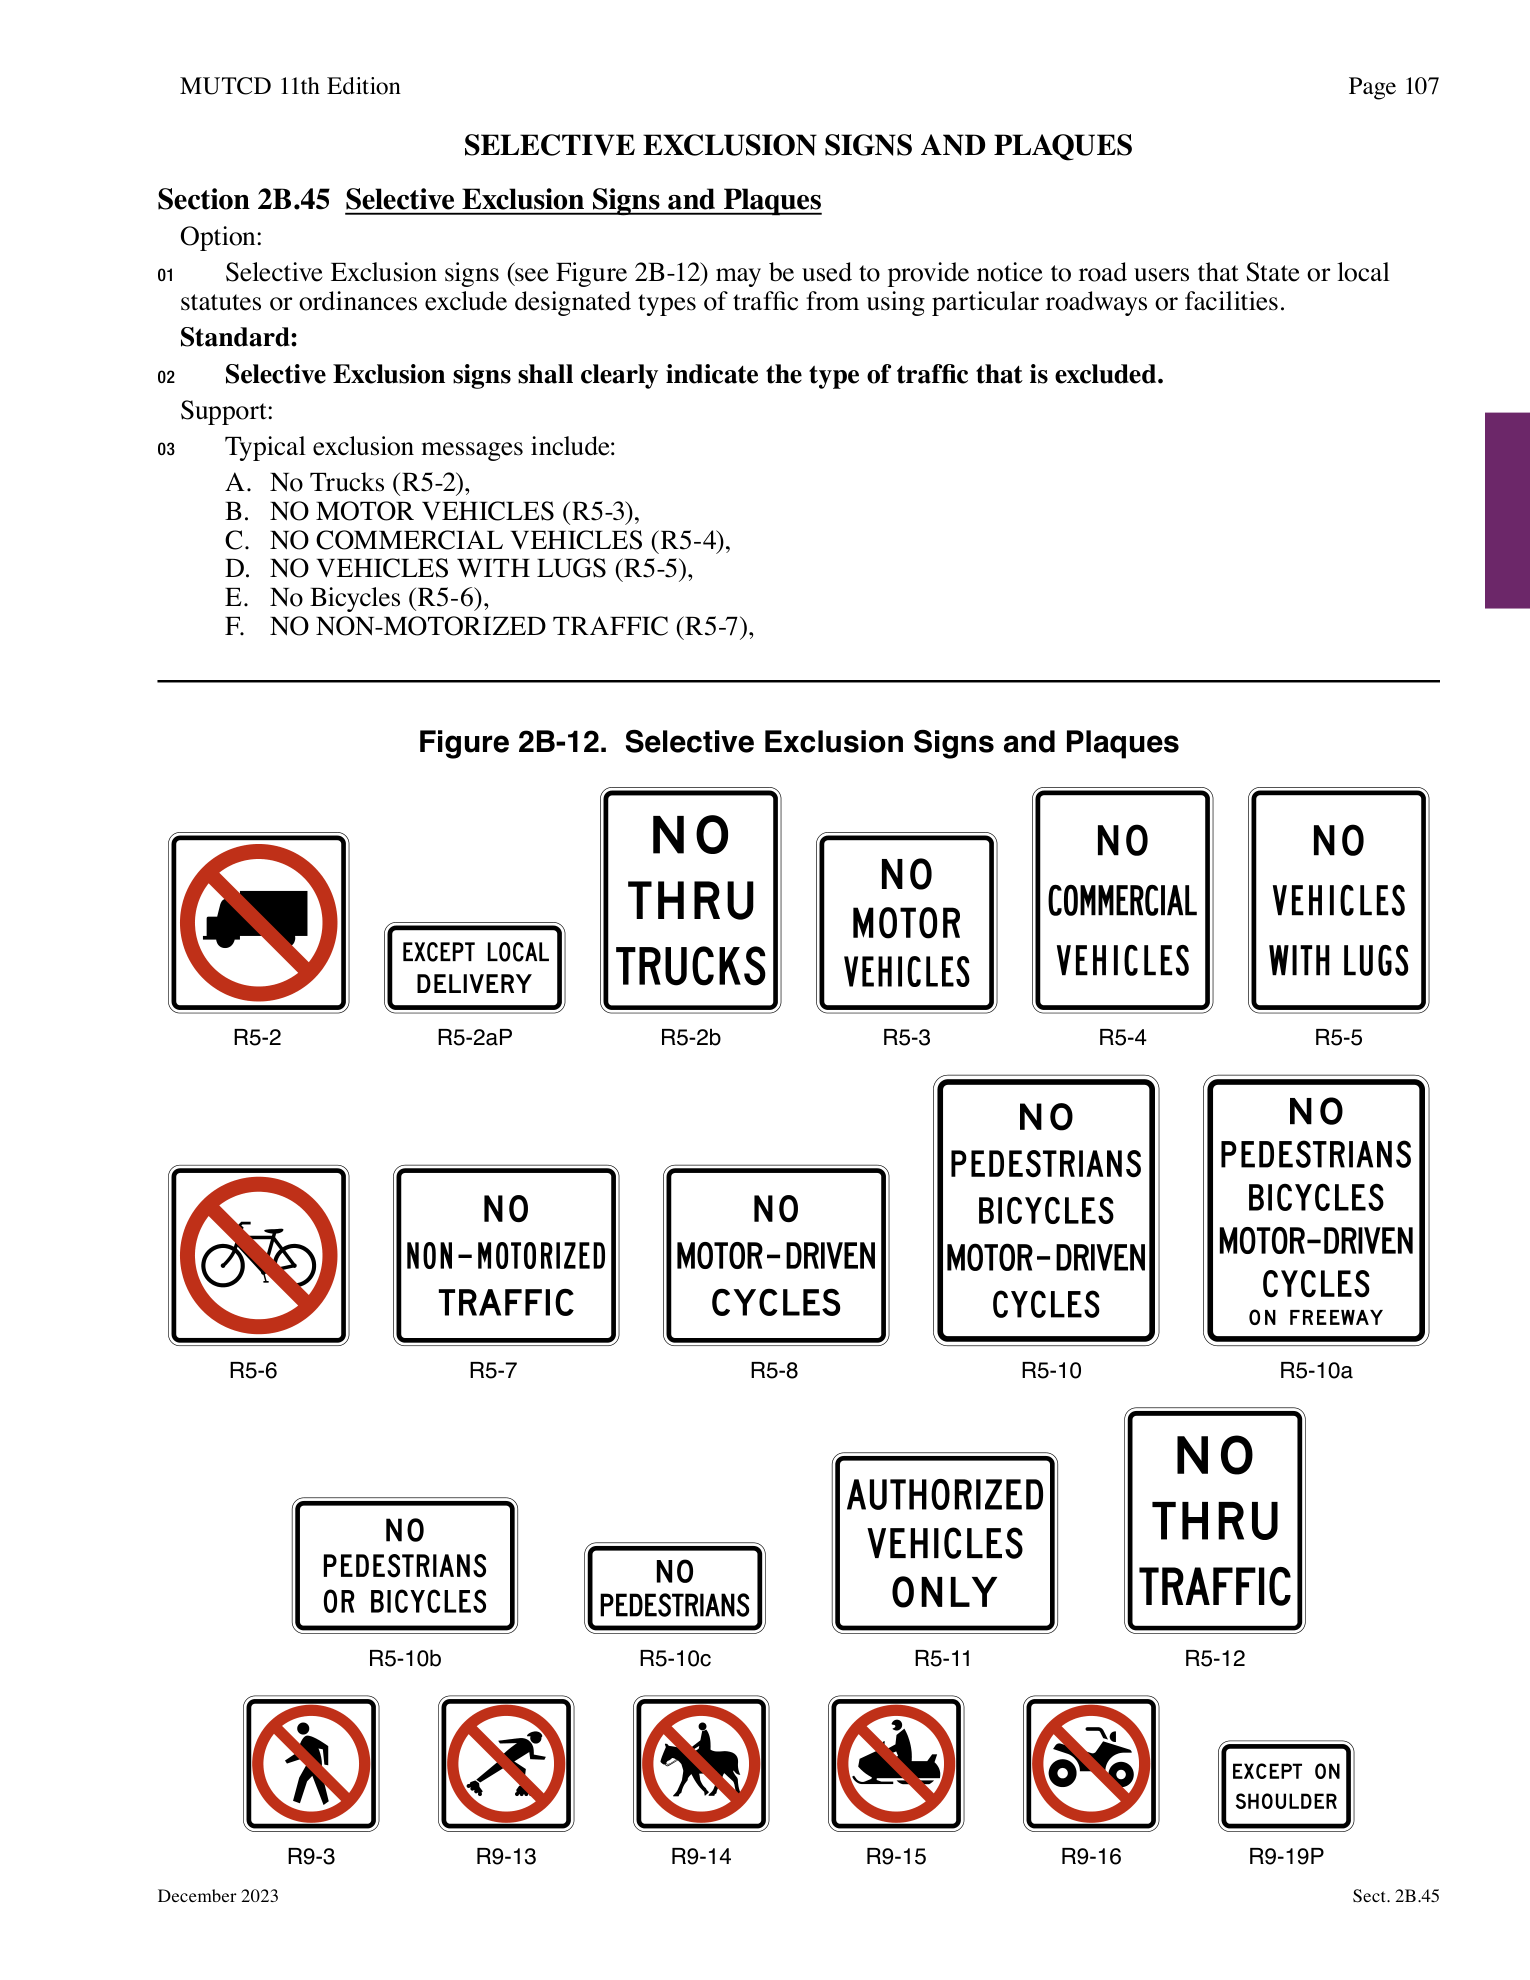

**[Page 4]** p.135 (score=15.009)

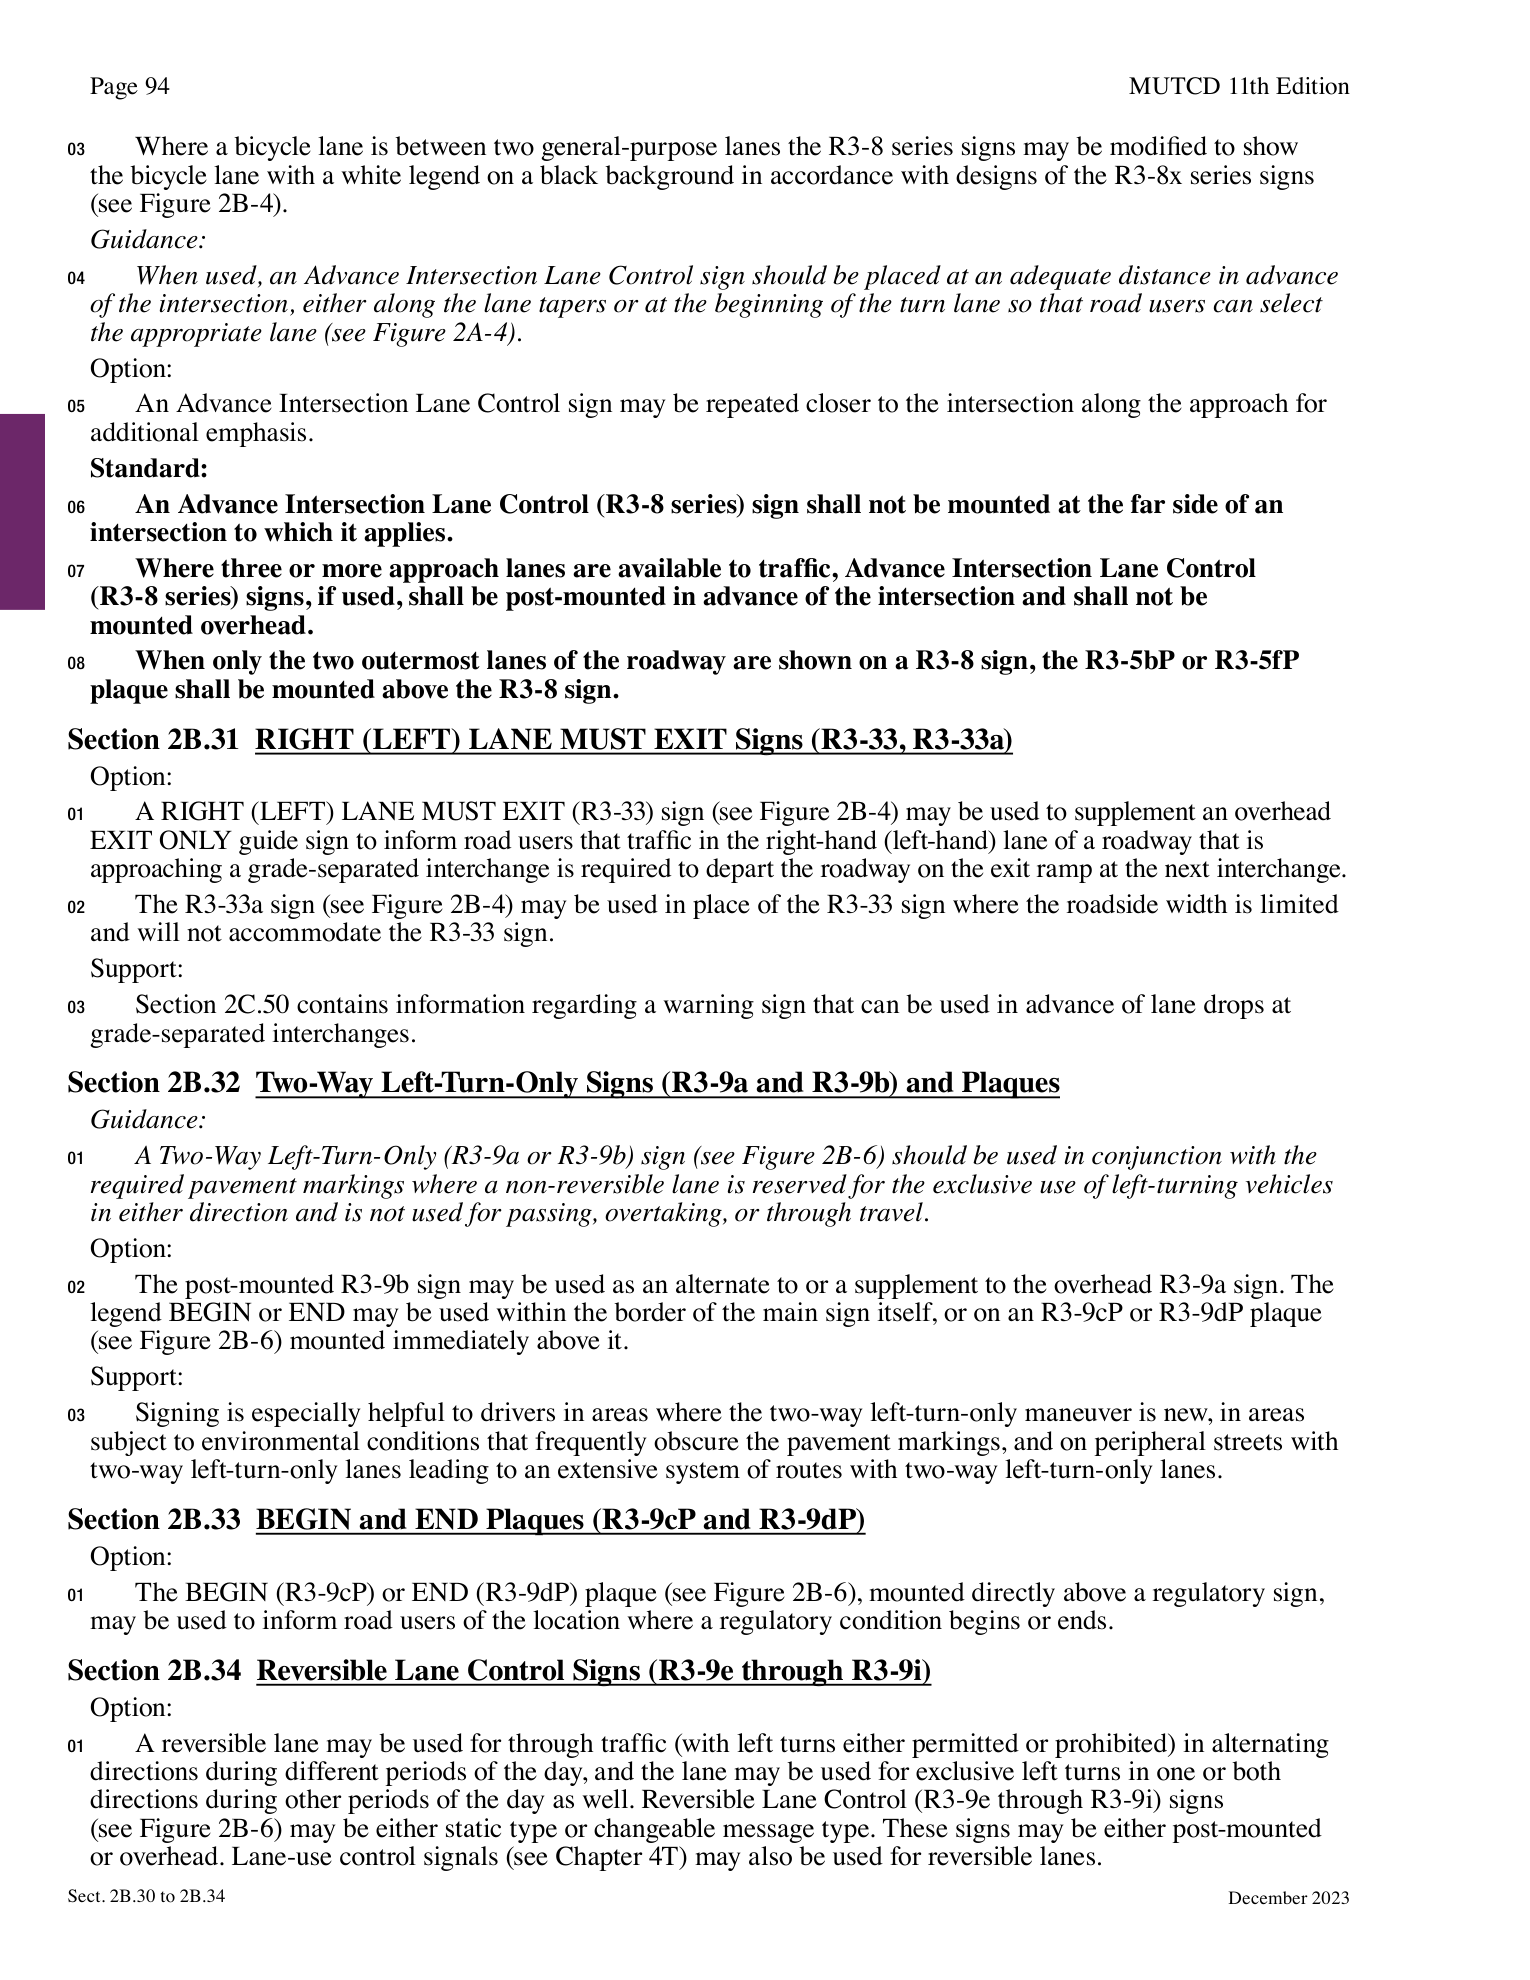

### Q
What does MUTCD say about pedestrian hybrid beacons?

### Answer

Direct Answer: Pedestrian hybrid beacons are traffic control devices used alongside signs and pavement markings to warn and control traffic at pedestrian crossing locations. They are strictly permitted only at marked crosswalks and must generally adhere to standard traffic signal provisions. The MUTCD also recommends maintaining clear sight distance around the crosswalk, coordinating the beacon with existing signal systems, and preempting the beacon if it is located near an active grade crossing.

Standards (mandatory):
- If used, pedestrian hybrid beacons shall be used in conjunction with signs and pavement markings (see Section 4J.02) to warn and control traffic at locations where pedestrians enter or cross a street or highway. A pedestrian hybrid beacon shall only be installed at a marked crosswalk.
- Except as otherwise provided in this Section, a pedestrian hybrid beacon shall meet the provisions of Chapters 4D through 4G, 4I, and 4J.

Guidance (recommended):
- When an engineering study justifies the installation of a pedestrian hybrid beacon, parking and sight obstructions should be prohibited for at least 100 feet in advance of and 20 feet beyond the marked crosswalk, or accommodated via curb extensions or other techniques.
- If installed within a signal system, the pedestrian hybrid beacon should be coordinated.
- The beacon sequence operates through several intervals: dark until activated, flashing yellow upon activation, steady yellow, steady red during the pedestrian walk interval, alternating flashing red during the pedestrian change interval, and dark again until activated. Optional steady red clearance and short buffer intervals may also be added.
- A pedestrian hybrid beacon should comply with the signal face location provisions described in Sections 4D.05 through 4D.10.
- A pedestrian hybrid beacon located 200 feet or less from an active grade crossing should be preempted in accordance with the applicable provisions in Sections 4F.19 and 8D.09.

Citations:
- Section 3C.02 Support §7 (p.590)
- Section 4J.01 Standard §3 (p.727)
- Section 4J.02 Standard §1 (p.728)
- Section 4J.02 Guidance §4 (p.729)
- Section 4J.02 Guidance §7 (p.729)
- Section 4J.03 Guidance §14 (p.730)

### Retrieved chunks

**3C.02 Support §7** — Application of Crosswalk Markings (p.590) · score=11.500

Chapter 4J contains information on pedestrian hybrid beacons....

**4J.01 Standard §3** — Application of Pedestrian Hybrid Beacons (p.727) · score=11.250

If used, pedestrian hybrid beacons shall be used in conjunction with signs and pavement markings (see Section 4J.02) to warn and control traffic at locations where pedestrians enter or cross a street or highway. A pedestrian hybrid beacon shall only be installed at a marked crosswalk....

**4J.02 Guidance §4** — Design of Pedestrian Hybrid Beacons (p.729) · score=11.250

When an engineering study finds that installation of a pedestrian hybrid beacon is justified, then: A. Parking and other sight obstructions should be prohibited for at least 100 feet in advance of and at least 20 feet beyond the marked crosswalk, or site accommodations should be made through curb extensions or other techniques to provide adequate sight distance; and B. If installed within a signal system, the pedestrian hybrid beacon should be coordinated. MUTCD 11th Edition - Revision 1 Figure 4J-3. Sequence for a Pedestrian Hybrid Beacon 1. Dark Until Activated 2. Flashing Yellow Upon Activa...

**4J.02 Guidance §7** — Design of Pedestrian Hybrid Beacons (p.729) · score=11.125

A pedestrian hybrid beacon should comply with the signal face location provisions described in Sections 4D.05 through 4D.10....

**4J.02 Standard §1** — Design of Pedestrian Hybrid Beacons (p.728) · score=11.000

Except as otherwise provided in this Section, a pedestrian hybrid beacon shall meet the provisions of Chapters 4D through 4G, 4I, and 4J....

**4J.03 Guidance §14** — Operation of Pedestrian Hybrid Beacons (p.730) · score=10.625

A pedestrian hybrid beacon that is located 200 feet or less from an active grade crossing should be preempted in accordance with the applicable provisions in Sections 4F.19 and 8D.09....

### Q
What does 'shall' mean in the MUTCD?

### Answer

Direct Answer: In the MUTCD, the verb "shall" is typically used to indicate a Standard statement. It defines a required, mandatory, or specifically prohibitive practice regarding a traffic control device. The verb "shall" is never used in Guidance statements.

Standards (mandatory):
- When used in this Manual, the text headings of Standard, Guidance, Option, and Support shall be defined as follows: A. Standard-a statement of required, mandatory, or specifically prohibitive practice regarding a traffic control device. In limited, location-specific cases, the results of a documented engineering study (see Section 1D.03) might indicate a deviation from one or more requirements of a Standard provision to be appropriate. All Standard statements are labeled, and the text appears in bold type. The verb “shall” is typically used. The verbs “should” and “may” are not used in Standard statements. Standard statements are sometimes modified by Option statements. B. Guidance-a statement of recommended practice in typical situations, with deviations allowed if engineering judgment or engineering study (see Section 1D.03) indicates the deviation to be appropriate. All Guidance statements are labeled, and the text appears in unbold italic type. The verb “should” is typically used. The verbs “shall” and “may” are not used in Guidance statements.

Citations:
- Section 1C.01 Standard §1 (p.13)

In [8]:
RUN_INTERACTIVE_TESTS = True

if RUN_INTERACTIVE_TESTS:
    interactive_model = next(
        iter(SELECTED_MODELS)
    )

    CFG.set_vlm_model(
        interactive_model
    )
    CFG.set_filter_model(None)

    _ = ask(
        "Explain Figure 2B-1 and the plaques it shows.",
        show_scores=True,
    )

    _ = ask(
        "What does MUTCD say about pedestrian hybrid beacons?",
        show_text=True,
    )

    _ = ask(
        "What does 'shall' mean in the MUTCD?",
        show_scores=True,
    )
else:
    print("Interactive tests are disabled.")


## 7. Optional knowledge-graph and retrieval inspection


In [12]:
RUN_DEBUG_INSPECTION = False

if RUN_DEBUG_INSPECTION:
    graph = pipeline.kg.g

    print(
        graph.number_of_nodes(),
        "nodes,",
        graph.number_of_edges(),
        "edges",
    )

    node_id = "signcode:R1-1"

    if node_id in graph:
        print(
            "Node:",
            graph.nodes[node_id],
        )
        print(
            "Neighbors:",
            list(
                graph.neighbors(
                    node_id
                )
            )[:30],
        )

    retrieval_result = (
        pipeline.retriever.retrieve(
            "Explain Figure 2B-1 and the plaques it shows."
        )
    )

    print(
        "Router:",
        retrieval_result.debug.get(
            "figure_router"
        ),
    )
    print(
        "Chunks:",
        len(
            retrieval_result.chunks
        ),
    )
    print(
        "Figures:",
        len(
            retrieval_result.figures
        ),
    )
    print(
        "Pages:",
        len(
            retrieval_result.pages
        ),
    )
else:
    print("Debug inspection is disabled.")


Debug inspection is disabled.


## 8. Load the MUTCD-150 benchmark

Runtime files come from the GitHub repository. Outputs are written to
Google Drive.

The immutable question-only SHA-256 is verified before a run begins.


In [7]:
import hashlib
import importlib
import json
import shutil
import sys
from pathlib import Path

REPO_BENCH_DIR = (
    REPO_DIR
    / "benchmarks"
    / "mutcd150"
    / "v1"
)

DRIVE_BENCH_DIR = (
    Path(CFG.base_dir)
    / "benchmarks"
    / "mutcd150"
    / "v1"
)
DRIVE_BENCH_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RUNNER_PATH = (
    REPO_BENCH_DIR
    / "mutcd_benchmark_runner.py"
)
QUESTIONS_PATH = (
    REPO_BENCH_DIR
    / "mutcd_benchmark_questions_v1.jsonl"
)
REPO_MODEL_REGISTRY_PATH = (
    REPO_BENCH_DIR
    / "model_registry.json"
)
DRIVE_MODEL_REGISTRY_PATH = (
    DRIVE_BENCH_DIR
    / "model_registry.json"
)
RUNTIME_MANIFEST_PATH = (
    REPO_BENCH_DIR
    / "runtime_manifest.json"
)

EXPECTED_QUESTIONS_SHA256 = (
    "3a04b1d620a80704eefac34c565449a0cb8814e781dd6d73b8"
    "afb77318b954b2"
)

def sha256_file(
    path: Path,
) -> str:
    digest = hashlib.sha256()

    with path.open(
        "rb"
    ) as stream:
        for block in iter(
            lambda: stream.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(
                block
            )

    return digest.hexdigest()

for required_path in [
    RUNNER_PATH,
    QUESTIONS_PATH,
    REPO_MODEL_REGISTRY_PATH,
    RUNTIME_MANIFEST_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            required_path
        )

actual_hash = sha256_file(
    QUESTIONS_PATH
)

if (
    actual_hash
    != EXPECTED_QUESTIONS_SHA256
):
    raise ValueError(
        "The benchmark question file was modified.\n"
        f"Expected: {EXPECTED_QUESTIONS_SHA256}\n"
        f"Received: {actual_hash}"
    )

if not DRIVE_MODEL_REGISTRY_PATH.exists():
    shutil.copy2(
        REPO_MODEL_REGISTRY_PATH,
        DRIVE_MODEL_REGISTRY_PATH,
    )

MODEL_REGISTRY_PATH = (
    DRIVE_MODEL_REGISTRY_PATH
)

if str(REPO_BENCH_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(REPO_BENCH_DIR),
    )

if "mutcd_benchmark_runner" in sys.modules:
    del sys.modules[
        "mutcd_benchmark_runner"
    ]

runner = importlib.import_module(
    "mutcd_benchmark_runner"
)

run_benchmark = runner.run_benchmark
validate_run_outputs = (
    runner.validate_run_outputs
)

print("Runner version:", runner.RUNNER_VERSION)
print("Question hash :", actual_hash)
print("Registry      :", MODEL_REGISTRY_PATH)

OUTPUT_ROOT = (
    Path(CFG.base_dir)
    / "benchmark_runs"
    / "mutcd150_v1"
)
OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


Runner version: 1.1.2
Question hash : 3a04b1d620a80704eefac34c565449a0cb8814e781dd6d73b8afb77318b954b2
Registry      : /content/drive/MyDrive/MRAG/benchmarks/mutcd150/v1/model_registry.json


## 9. Build the selected model list

This does not permanently rewrite the model registry. It only creates
the list used in the current notebook session.


In [8]:
import json

registry_document = json.loads(
    MODEL_REGISTRY_PATH.read_text(
        encoding="utf-8"
    )
)

all_model_specs = registry_document["models"]

MODEL_REGISTRY = [
    model
    for model in all_model_specs
    if (
        model.get("alias")
        in SELECTED_MODELS
        or model.get("selector")
        in SELECTED_MODELS
    )
]

if not MODEL_REGISTRY:
    raise ValueError(
        "None of SELECTED_MODELS were found in model_registry.json."
    )

print("Models for this session:")

for model in MODEL_REGISTRY:
    print(
        " ",
        model["alias"],
        "->",
        model["selector"],
        "[",
        model.get("provider"),
        "]",
    )

# Keep the figure filter following whichever answer model the runner
# selects during the loop.
CFG.use_vlm_figure_filter = True
CFG.set_filter_model(None)


Models for this session:
  balanced_gemini -> balanced_gemini [ google ]


## 10. Five-question smoke test

Run this first. It covers text, table, figure, and mixed questions.

Change `RUN_SMOKE_TEST` to `True` when ready.


In [9]:
import json

RUN_SMOKE_TEST = True

# Put the model aliases directly here.
# No model_registry.json filtering is involved.
SMOKE_MODELS = [
    "balanced_gemini",
]

SMOKE_QUESTION_IDS = [
    "T017",
    "TB005",
    "F005",
    "M008",
    "M024",
]

# Use a new run ID.
SMOKE_RUN_ID = "mutcd150_smoke_balanced_gemini_01"

if RUN_SMOKE_TEST:
    assert SMOKE_MODELS, "SMOKE_MODELS is empty."

    # Confirm the model and provider before running.
    for model_alias in SMOKE_MODELS:
        resolved_model = CFG.set_vlm_model(model_alias)

        print(
            f"{model_alias} -> {resolved_model}"
        )

    # The selected answer model also performs figure filtering.
    CFG.use_vlm_figure_filter = True
    CFG.set_filter_model(None)

    print("\nModels passed to runner:", SMOKE_MODELS)
    print(
        "Figure-filter override:",
        CFG.vlm_model_filter,
    )
    print(
        "Current effective filter model:",
        CFG.vlm_model_api,
    )

    smoke_paths = run_benchmark(
        CFG=CFG,
        ask_fn=ask,
        questions_path=QUESTIONS_PATH,
        output_root=OUTPUT_ROOT,
        run_id=SMOKE_RUN_ID,

        # IMPORTANT: pass aliases directly.
        models=SMOKE_MODELS,

        prompt_style=PROMPT_STYLE,
        replicates=1,
        question_ids=SMOKE_QUESTION_IDS,
        show_scores=True,
        show_text=True,
        max_attempts=5,
        retry_base_seconds=8.0,
        inter_request_seconds=2.0,
        seed=20260710,
        resume=True,
        rerun_errors=True,
        strict_benchmark_hash=True,
        strict_question_count=True,
        store_serialized_return=True,
        store_raw_debug=True,
        echo_answer_preview=True,
    )

    smoke_summary = validate_run_outputs(
        smoke_paths["run_dir"],
        SMOKE_RUN_ID,
    )

    print(
        json.dumps(
            smoke_summary,
            indent=2,
        )
    )

    expected_records = (
        len(SMOKE_QUESTION_IDS)
        * len(SMOKE_MODELS)
    )

    assert smoke_summary["ok_records"] == expected_records, (
        f"Expected {expected_records} successful records, "
        f"but received {smoke_summary['ok_records']}."
    )

    assert smoke_summary["error_records"] == 0
    assert smoke_summary["unresolved_error_records"] == 0

    print(
        f"\nSmoke test completed: "
        f"{smoke_summary['ok_records']}/{expected_records}"
    )

else:
    print("Smoke test is disabled.")

balanced_gemini -> gemini-3.5-flash

Models passed to runner: ['balanced_gemini']
Figure-filter override: None
Current effective filter model: gemini-3.5-flash

=== Model 'balanced_gemini' (selector='balanced_gemini') ===
[1/5] RUN  balanced_gemini T017 r1


You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


  OK 65921 ms — Direct Answer: Generally, word messages on signs must be aligned horizontally and read from left to right using standard wording, though minor modifications to layout are permitted. For community wayfinding and shared-use path guide signs, 
[2/5] RUN  balanced_gemini TB005 r1


  OK 60515 ms — Direct Answer: According to the MUTCD, specific sign shapes from Table 2A-1 are reserved exclusively for particular signs. The octagon shape is used exclusively for the STOP (R1-1) sign, the circle shape is used for the Grade Crossing Advan
[3/5] RUN  balanced_gemini F005 r1
  OK 22734 ms — Direct Answer: In the channelized-intersection example (Diagram B) of Figure 2A-3, the YIELD sign is shown at a distance of 6 to 12 feet minimum from the nose of the channelizing island. This is indicated by the dimension label "6 ft to 12 
[4/5] RUN  balanced_gemini M008 r1


  OK 80647 ms — Direct Answer: On a multi-lane roadway posted at 35 mph, the single-lane regulatory-sign size may not be used because multi-lane approaches require the larger dimensions specified in the multi-lane columns. Under these conditions, a STOP (R
[5/5] RUN  balanced_gemini M024 r1


  OK 74052 ms — Direct Answer: A bicycle box must have a minimum length of 10 feet and must contain at least one bicycle symbol marking. Motor vehicle turns on red are strictly prohibited from any lane containing a bicycle box. If green-colored pavement is

Run complete
 answers : /content/drive/MyDrive/MRAG/benchmark_runs/mutcd150_v1/mutcd150_smoke_balanced_gemini_01/answers_mutcd150_smoke_balanced_gemini_01.jsonl
 retrieval: /content/drive/MyDrive/MRAG/benchmark_runs/mutcd150_v1/mutcd150_smoke_balanced_gemini_01/retrieval_mutcd150_smoke_balanced_gemini_01.jsonl
 manifest: /content/drive/MyDrive/MRAG/benchmark_runs/mutcd150_v1/mutcd150_smoke_balanced_gemini_01/manifest_mutcd150_smoke_balanced_gemini_01.json
{
  "run_id": "mutcd150_smoke_balanced_gemini_01",
  "answer_records_raw": 5,
  "successful_records": 5,
  "historical_answer_duplicates": 0,
  "error_events": 0,
  "unresolved_error_records": 0,
  "unresolved_error_keys": [],
  "unique_models": [
    "balanced_gemini"
  ],
  "uniq

## 11. Full 150-question benchmark

Keep `RUN_FULL_BENCHMARK=False` until the smoke-test output is clean.

Change `PRIMARY_RUN_ID` whenever the selected models or configuration
changes.


In [13]:
import json

# ---------------------------------------------------------------------------
# Full MUTCD-150 benchmark
# ---------------------------------------------------------------------------

RUN_FULL_BENCHMARK = True

# Put the model alias directly here.
# Run one model at a time to keep outputs and retries separate.
BENCHMARK_MODELS = [
    "balanced_gemini",
]

# Use a unique run ID for this model and configuration.
PRIMARY_RUN_ID = "mutcd150_primary_balanced_gemini_01"

if RUN_FULL_BENCHMARK:
    if not BENCHMARK_MODELS:
        raise ValueError(
            "BENCHMARK_MODELS is empty. Add at least one model alias."
        )

    # Verify every selected model before beginning the 150-question run.
    print("Models selected for the full run:")

    for model_alias in BENCHMARK_MODELS:
        resolved_model = CFG.set_vlm_model(model_alias)

        print(
            f"  {model_alias} -> {resolved_model}"
        )

    # The currently selected VLM performs both:
    # 1. figure filtering
    # 2. final answer generation
    CFG.use_vlm_figure_filter = True
    CFG.set_filter_model(None)

    print(
        "\nFigure-filter override:",
        CFG.vlm_model_filter,
    )
    print(
        "Filter policy:",
        "follow each selected answer model",
    )
    print(
        "Run ID:",
        PRIMARY_RUN_ID,
    )

    primary_paths = run_benchmark(
        CFG=CFG,
        ask_fn=ask,
        questions_path=QUESTIONS_PATH,
        output_root=OUTPUT_ROOT,
        run_id=PRIMARY_RUN_ID,

        # Pass model aliases directly.
        models=BENCHMARK_MODELS,

        prompt_style=PROMPT_STYLE,
        replicates=1,

        # Run all 150 questions.
        max_questions=None,
        question_ids=None,

        show_scores=False,
        show_text=False,
        max_attempts=3,
        retry_base_seconds=8.0,
        inter_request_seconds=2.0,
        seed=20260710,
        resume=True,
        rerun_errors=True,
        strict_benchmark_hash=True,
        strict_question_count=True,
        store_serialized_return=True,
        store_raw_debug=True,
        echo_answer_preview=True,
    )

    primary_summary = validate_run_outputs(
        primary_paths["run_dir"],
        PRIMARY_RUN_ID,
    )

    print(
        json.dumps(
            primary_summary,
            indent=2,
        )
    )

    expected_records = (
        150 * len(BENCHMARK_MODELS)
    )

    assert primary_summary["ok_records"] == expected_records, (
        f"Expected {expected_records} successful records, "
        f"but received {primary_summary['ok_records']}. "
        "Inspect the errors file and run validation before retrying."
    )

    assert primary_summary["error_records"] == 0, (
        "The run contains unresolved error records."
    )

    assert (
        primary_summary["unresolved_error_records"]
        == 0
    ), (
        "The run contains unresolved provider or runtime failures."
    )

    print(
        "\nFull benchmark completed successfully:",
        f"{primary_summary['ok_records']}/{expected_records}",
    )
    print(
        "Run directory:",
        primary_paths["run_dir"],
    )

else:
    print(
        "Full benchmark is disabled. "
        "Set RUN_FULL_BENCHMARK=True after the smoke test passes."
    )

Models selected for the full run:
  balanced_gemini -> gemini-3.5-flash

Figure-filter override: None
Filter policy: follow each selected answer model
Run ID: mutcd150_primary_balanced_gemini_01

=== Model 'balanced_gemini' (selector='balanced_gemini') ===
[1/150] RUN  balanced_gemini T001 r1
  OK 13463 ms — Direct Answer: The purpose of the MUTCD is to establish uniform national criteria for the use of traffic control devices that meet the needs and expectancy of road users on all streets, highways, pedestrian and bicycle facilities, and site 
[2/150] RUN  balanced_gemini T002 r1
  OK 27453 ms — Direct Answer: The applicability of the MUTCD to a facility open to public travel does not depend on whether the facility is publicly or privately owned, or on its source of funding. Instead, its applicability is entirely independent of the
[3/150] RUN  balanced_gemini T003 r1
  OK 16164 ms — Direct Answer: No, the MUTCD does not consider islands, curbs, speed humps, raised roadway surfaces, o

  OK 86658 ms — Direct Answer: Generally, word messages on signs must be aligned horizontally and read from left to right using standard wording, though minor layout modifications are permitted. Casing rules depend on the sign type; for instance, destinati
[18/150] RUN  balanced_gemini T018 r1
  OK 14792 ms — Direct Answer: A NEW plaque should remain in place for a period of time determined by engineering judgment, but it must be removed no later than 12 months after installation. Strobe lights are prohibited and shall not be used to enhance the
[19/150] RUN  balanced_gemini T019 r1


  OK 68400 ms — Direct Answer: In rural areas, the minimum mounting height for roadside signs is 5 feet, measured vertically from the bottom of the sign to the elevation of the near edge of the pavement. In business, commercial, or residential areas where 
[20/150] RUN  balanced_gemini T020 r1


  OK 76526 ms — Direct Answer: Overhead signs are required to have a minimum vertical clearance of 17 feet to the sign, light fixture, or sign bridge over the entire width of the pavement and shoulders. This clearance can be reduced if the mounting structu
[21/150] RUN  balanced_gemini T021 r1
  OK 34783 ms — Direct Answer: Regulatory signs must be installed at or near the locations where the corresponding regulations apply. To ensure visibility at night, these signs are required to be either retroreflective or illuminated. Additionally, they mu
[22/150] RUN  balanced_gemini T022 r1
  OK 17298 ms — Direct Answer: At intersections where all approaches are controlled by STOP signs, an ALL-WAY (R1-3P) supplemental plaque is required to be mounted below each STOP sign. Supplemental plaques displaying legends such as 2-WAY, 3-WAY, 4-WAY, o
[23/150] RUN  balanced_gemini T023 r1
  OK 29117 ms — Direct Answer: At a roundabout, a YIELD sign must be used to require road users to yield the right-

  OK 56841 ms — Direct Answer: A Speed Limit sign must display the limit established by law, ordinance, regulation, or as adopted by an authorized agency based on an engineering study. These displayed limits must be in multiples of 5 mph. A Speed Limit sig
[26/150] RUN  balanced_gemini T026 r1
  OK 26949 ms — Direct Answer: The provided evidence is insufficient to determine the three types of signs required at an interchange exit-ramp terminal where wrong-way entry could inadvertently occur. Although the DO NOT ENTER (R5-1) sign is identified as
[27/150] RUN  balanced_gemini T027 r1


...

  OK 56168 ms — Direct Answer: When entering a reduced school speed-limit zone, drivers must first pass an advance School (S1-1) sign, which may be followed by a Reduced School Speed Limit Ahead (S4-5) sign. A School Speed Limit assembly or School Speed Li
[143/150] RUN  balanced_gemini M023 r1


  OK 21295 ms — Direct Answer: From top to bottom, the vertical order of a passive-crossing assembly on a single support with multiple tracks consists of the Crossbuck (R15-1) sign, followed by the Number of Tracks (R15-2P) plaque, and either a YIELD (R1-2
[144/150] RUN  balanced_gemini M024 r1


  OK 61101 ms — Direct Answer: A bicycle box must be at least 10 feet in length from the upstream motor vehicle stop line to the downstream crosswalk or intersection, and it must contain at least one bicycle symbol marking. Turns on red are strictly prohib
[145/150] RUN  balanced_gemini M025 r1
  OK 24378 ms — Direct Answer: The provided evidence is insufficient to answer the question. The MUTCD text and figures describe technical and dimensional specifications for arrow boards, but they do not contain any information regarding the purchase, inst
[146/150] RUN  balanced_gemini M026 r1


ERROR:mrag.ask:VLM generation failed
Traceback (most recent call last):
  File "/content/MRAG/mrag/ask.py", line 119, in ask
    answer = p.vlm.answer(
             ^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 252, in answer
    return self._answer_api(prompt, image_paths, max_new_tokens)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 933, in _answer_api
    response = self._client_for(
               ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_utils/_utils.py", line 298, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/resources/chat/completions/completions.py", line 1281, in create
    return self._post(
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_base_client.py", line 1332, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_c

  attempt 1 failed (VLMResponseError: (VLM error: InternalServerError("Error code: 503 - [{'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}]"))); retrying in 8.3s
  OK 9701 ms — Direct Answer: The provided text evidence is insufficient to answer the question. There is no information specifying which MUTCD provisions have been adopted without modification by each state, nor is there any mention of fines associated w
[147/150] RUN  balanced_gemini M027 r1
  OK 7802 ms — The provided evidence is insufficient to answer the question. The text does not mention or recommend any vision-language models, embedding models, or vector databases for automated-vehicle traffic-control-device recognition.
[148/150] RUN  balanced_gemini M028 r1
  OK 10778 ms — Direct Answer: The provided evidence is insufficient to answer the question. There is no information in the text or vis

## 12. Check a completed run for runtime problems

Enter the run ID you want to inspect. This checks missing, empty,
error, retry, and provider-truncation records. It does not judge
substantive answer correctness.


In [14]:
import json
import re
from pathlib import Path

RUN_ID_TO_CHECK = PRIMARY_RUN_ID

def read_jsonl(
    path: Path,
) -> list[dict]:
    if not path.exists():
        return []

    return [
        json.loads(line)
        for line in path.read_text(
            encoding="utf-8"
        ).splitlines()
        if line.strip()
    ]

def natural_sort(
    question_id: str,
):
    match = re.match(
        r"([A-Za-z]+)(\d+)",
        question_id,
    )

    if not match:
        return (
            question_id,
            0,
        )

    return (
        match.group(1),
        int(match.group(2)),
    )

run_dir = (
    OUTPUT_ROOT
    / RUN_ID_TO_CHECK
)

answers = read_jsonl(
    run_dir
    / f"answers_{RUN_ID_TO_CHECK}.jsonl"
)
errors = read_jsonl(
    run_dir
    / f"errors_{RUN_ID_TO_CHECK}.jsonl"
)

retried_ids = set()
invalid_ids = set()
truncated_ids = set()

for record in answers:
    question_id = str(
        record.get(
            "question_id",
            "",
        )
    )

    if int(
        record.get(
            "attempts",
            1,
        )
        or 1
    ) > 1:
        retried_ids.add(
            question_id
        )

    answer = str(
        record.get(
            "answer",
            "",
        )
        or ""
    ).strip()

    serialized = (
        record.get(
            "serialized_return"
        )
        or {}
    )
    serialized_answer = str(
        serialized.get(
            "answer",
            "",
        )
        or ""
    ).strip()

    if (
        str(
            record.get(
                "status",
                "",
            )
        ).lower()
        != "ok"
        or not answer
        or not serialized_answer
        or answer.startswith(
            "### "
        )
        or answer.lower().startswith(
            (
                "(vlm error:",
                "vlm error:",
            )
        )
    ):
        invalid_ids.add(
            question_id
        )

    stop_reason = (
        serialized.get(
            "debug",
            {}
        )
        .get(
            "vlm_response",
            {}
        )
        .get(
            "stop_reason"
        )
    )

    if str(
        stop_reason
        or ""
    ).lower() in {
        "length",
        "max_tokens",
        "model_context_window_exceeded",
    }:
        truncated_ids.add(
            question_id
        )

unresolved_ids = {
    str(
        record.get(
            "question_id",
            "",
        )
    )
    for record in errors
    if record.get(
        "question_id"
    )
}

all_problem_ids = sorted(
    invalid_ids
    | truncated_ids
    | unresolved_ids,
    key=natural_sort,
)

print("Required a retry but succeeded:")
print(
    sorted(
        retried_ids
        - invalid_ids
        - truncated_ids
        - unresolved_ids,
        key=natural_sort,
    )
)

print("\nInvalid or empty:")
print(
    sorted(
        invalid_ids,
        key=natural_sort,
    )
)

print("\nTruncated:")
print(
    sorted(
        truncated_ids,
        key=natural_sort,
    )
)

print("\nUnresolved errors:")
print(
    sorted(
        unresolved_ids,
        key=natural_sort,
    )
)

print("\nQuestions requiring selective retry:")
print(all_problem_ids)


Required a retry but succeeded:
['M026', 'T027', 'T038']

Invalid or empty:
[]

Truncated:
[]

Unresolved errors:
[]

Questions requiring selective retry:
[]


In [10]:
import json

# ---------------------------------------------------------------------------
# Selective retry
# ---------------------------------------------------------------------------

RUN_SELECTIVE_RETRY = True

# Pass the model alias directly.
RETRY_MODELS = [
    "balanced_gemini",
]

RETRY_QUESTION_IDS = [
    "M026",
    "T027",
    "T038",
]

# Always use a new run ID for a new retry batch.
RETRY_RUN_ID = "retry_balanced_gemini_01"

if RUN_SELECTIVE_RETRY:
    if not RETRY_MODELS:
        raise ValueError(
            "RETRY_MODELS is empty. Add at least one model alias."
        )

    if not RETRY_QUESTION_IDS:
        raise ValueError(
            "RETRY_QUESTION_IDS is empty."
        )

    if not RETRY_RUN_ID:
        raise ValueError(
            "Set a unique RETRY_RUN_ID."
        )

    # Remove accidental duplicate question IDs while preserving order.
    RETRY_QUESTION_IDS = list(
        dict.fromkeys(RETRY_QUESTION_IDS)
    )

    print("Retry model or models:")

    for model_alias in RETRY_MODELS:
        resolved_model = CFG.set_vlm_model(
            model_alias
        )

        print(
            f"  {model_alias} -> {resolved_model}"
        )

    # The selected VLM performs both figure filtering and final answering.
    CFG.use_vlm_figure_filter = True
    CFG.set_filter_model(None)

    print(
        "\nModels passed to runner:",
        RETRY_MODELS,
    )
    print(
        "Questions to retry:",
        len(RETRY_QUESTION_IDS),
    )
    print(
        "Figure-filter override:",
        CFG.vlm_model_filter,
    )
    print(
        "Filter policy:",
        "follow the selected answer model",
    )
    print(
        "Retry run ID:",
        RETRY_RUN_ID,
    )

    retry_paths = run_benchmark(
        CFG=CFG,
        ask_fn=ask,
        questions_path=QUESTIONS_PATH,
        output_root=OUTPUT_ROOT,
        run_id=RETRY_RUN_ID,

        # Pass aliases directly—do not use retry_specs or all_model_specs.
        models=RETRY_MODELS,

        prompt_style=PROMPT_STYLE,
        replicates=1,
        question_ids=RETRY_QUESTION_IDS,
        show_scores=True,
        show_text=True,
        max_attempts=3,
        retry_base_seconds=8.0,
        inter_request_seconds=2.0,
        seed=20260710,
        resume=True,
        rerun_errors=True,
        strict_benchmark_hash=True,
        strict_question_count=True,
        store_serialized_return=True,
        store_raw_debug=True,
        echo_answer_preview=True,
    )

    retry_summary = validate_run_outputs(
        retry_paths["run_dir"],
        RETRY_RUN_ID,
    )

    print(
        json.dumps(
            retry_summary,
            indent=2,
        )
    )

    expected_records = (
        len(RETRY_QUESTION_IDS)
        * len(RETRY_MODELS)
    )

    assert retry_summary["ok_records"] == expected_records, (
        f"Expected {expected_records} successful records, "
        f"but received {retry_summary['ok_records']}."
    )

    assert retry_summary["error_records"] == 0, (
        "The retry contains unresolved error records."
    )

    assert (
        retry_summary["unresolved_error_records"]
        == 0
    ), (
        "The retry contains unresolved provider or runtime failures."
    )

    print(
        "\nSelective retry completed successfully:",
        f"{retry_summary['ok_records']}/{expected_records}",
    )
    print(
        "Run directory:",
        retry_paths["run_dir"],
    )

else:
    print("Selective retry is disabled.")

Retry model or models:
  balanced_gemini -> gemini-3.5-flash

Models passed to runner: ['balanced_gemini']
Questions to retry: 3
Figure-filter override: None
Filter policy: follow the selected answer model
Retry run ID: retry_balanced_gemini_01

=== Model 'balanced_gemini' (selector='balanced_gemini') ===
[1/3] RUN  balanced_gemini T027 r1


  OK 61562 ms — Direct Answer: The advance placement of warning signs should be determined based on factors such as roadway type, conditions, and posted or 85th-percentile speeds, utilizing the distances specified in Table 2C-3 and Table 6B-1. Signs should
[2/3] RUN  balanced_gemini T038 r1
  OK 17070 ms — Direct Answer: A walking speed of 3.5 feet per second is generally recommended to calculate pedestrian clearance time. At locations where an extended push button press function is installed, an alternative walking speed of up to 4 feet per 
[3/3] RUN  balanced_gemini M026 r1
  OK 9103 ms — Direct Answer: The provided evidence is insufficient to answer the question. There is no information in the provided text detailing which specific MUTCD provisions have been adopted without modification by each State, nor is there any menti

Run complete
 answers : /content/drive/MyDrive/MRAG/benchmark_runs/mutcd150_v1/retry_balanced_gemini_01/answers_retry_balanced_gemini_01.jsonl
 retrieval: /con

## 13. Selective retry

Rerun only genuine runtime/provider failures, empty answers, confirmed
truncation, missing records, or corrupted outputs.

Do not rerun an answer only because it is wrong.


In [17]:
import json

# ---------------------------------------------------------------------------
# Selective retry
# ---------------------------------------------------------------------------

RUN_SELECTIVE_RETRY = True

# Pass the model alias directly.
RETRY_MODELS = [
    "frontier_gemini",
]

RETRY_QUESTION_IDS = [
    "M017",
    "M018",
    "M019",
    "M020",
    "M021",
    "M022",
    "M023",
    "M024",
    "M025",
    "M026",
    "M027",
    "M028",
    "M029",
    "M030",
]

# Always use a new run ID for a new retry batch.
RETRY_RUN_ID = "retry_frontier_gemini_01"

if RUN_SELECTIVE_RETRY:
    if not RETRY_MODELS:
        raise ValueError(
            "RETRY_MODELS is empty. Add at least one model alias."
        )

    if not RETRY_QUESTION_IDS:
        raise ValueError(
            "RETRY_QUESTION_IDS is empty."
        )

    if not RETRY_RUN_ID:
        raise ValueError(
            "Set a unique RETRY_RUN_ID."
        )

    # Remove accidental duplicate question IDs while preserving order.
    RETRY_QUESTION_IDS = list(
        dict.fromkeys(RETRY_QUESTION_IDS)
    )

    print("Retry model or models:")

    for model_alias in RETRY_MODELS:
        resolved_model = CFG.set_vlm_model(
            model_alias
        )

        print(
            f"  {model_alias} -> {resolved_model}"
        )

    # The selected VLM performs both figure filtering and final answering.
    CFG.use_vlm_figure_filter = True
    CFG.set_filter_model(None)

    print(
        "\nModels passed to runner:",
        RETRY_MODELS,
    )
    print(
        "Questions to retry:",
        len(RETRY_QUESTION_IDS),
    )
    print(
        "Figure-filter override:",
        CFG.vlm_model_filter,
    )
    print(
        "Filter policy:",
        "follow the selected answer model",
    )
    print(
        "Retry run ID:",
        RETRY_RUN_ID,
    )

    retry_paths = run_benchmark(
        CFG=CFG,
        ask_fn=ask,
        questions_path=QUESTIONS_PATH,
        output_root=OUTPUT_ROOT,
        run_id=RETRY_RUN_ID,

        # Pass aliases directly—do not use retry_specs or all_model_specs.
        models=RETRY_MODELS,

        prompt_style=PROMPT_STYLE,
        replicates=1,
        question_ids=RETRY_QUESTION_IDS,
        show_scores=True,
        show_text=True,
        max_attempts=3,
        retry_base_seconds=8.0,
        inter_request_seconds=2.0,
        seed=20260710,
        resume=True,
        rerun_errors=True,
        strict_benchmark_hash=True,
        strict_question_count=True,
        store_serialized_return=True,
        store_raw_debug=True,
        echo_answer_preview=True,
    )

    retry_summary = validate_run_outputs(
        retry_paths["run_dir"],
        RETRY_RUN_ID,
    )

    print(
        json.dumps(
            retry_summary,
            indent=2,
        )
    )

    expected_records = (
        len(RETRY_QUESTION_IDS)
        * len(RETRY_MODELS)
    )

    assert retry_summary["ok_records"] == expected_records, (
        f"Expected {expected_records} successful records, "
        f"but received {retry_summary['ok_records']}."
    )

    assert retry_summary["error_records"] == 0, (
        "The retry contains unresolved error records."
    )

    assert (
        retry_summary["unresolved_error_records"]
        == 0
    ), (
        "The retry contains unresolved provider or runtime failures."
    )

    print(
        "\nSelective retry completed successfully:",
        f"{retry_summary['ok_records']}/{expected_records}",
    )
    print(
        "Run directory:",
        retry_paths["run_dir"],
    )

else:
    print("Selective retry is disabled.")

Retry model or models:
  frontier_gemini -> gemini-3.1-pro-preview

Models passed to runner: ['frontier_gemini']
Questions to retry: 14
Figure-filter override: None
Filter policy: follow the selected answer model
Retry run ID: retry_frontier_gemini_01

=== Model 'frontier_gemini' (selector='frontier_gemini') ===
[1/14] RUN  frontier_gemini M017 r1


ERROR:mrag.ask:VLM generation failed
Traceback (most recent call last):
  File "/content/MRAG/mrag/ask.py", line 119, in ask
    answer = p.vlm.answer(
             ^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 252, in answer
    return self._answer_api(prompt, image_paths, max_new_tokens)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 933, in _answer_api
    response = self._client_for(
               ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_utils/_utils.py", line 298, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/resources/chat/completions/completions.py", line 1281, in create
    return self._post(
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_base_client.py", line 1332, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_c

  attempt 1 failed (VLMResponseError: (VLM error: RateLimitError("Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_requests_per_model_per_day, limit: 250, model: gemini-3.1-pro\\nPlease retry in 19h59m14.127386261s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_requests_per_model_per_day', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel', 'quotaDimensions': {'loca

ERROR:mrag.ask:VLM generation failed
Traceback (most recent call last):
  File "/content/MRAG/mrag/ask.py", line 119, in ask
    answer = p.vlm.answer(
             ^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 252, in answer
    return self._answer_api(prompt, image_paths, max_new_tokens)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 933, in _answer_api
    response = self._client_for(
               ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_utils/_utils.py", line 298, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/resources/chat/completions/completions.py", line 1281, in create
    return self._post(
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_base_client.py", line 1332, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_c

  attempt 2 failed (VLMResponseError: (VLM error: RateLimitError("Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_requests_per_model_per_day, limit: 250, model: gemini-3.1-pro\\nPlease retry in 19h59m0.283008903s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_requests_per_model_per_day', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel', 'quotaDimensions': {'locat

...

ERROR:mrag.ask:VLM generation failed
Traceback (most recent call last):
  File "/content/MRAG/mrag/ask.py", line 119, in ask
    answer = p.vlm.answer(
             ^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 252, in answer
    return self._answer_api(prompt, image_paths, max_new_tokens)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 933, in _answer_api
    response = self._client_for(
               ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_utils/_utils.py", line 298, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/resources/chat/completions/completions.py", line 1281, in create
    return self._post(
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_base_client.py", line 1332, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_c

  ERROR after 3 attempts: VLMResponseError: (VLM error: RateLimitError("Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_requests_per_model_per_day, limit: 250, model: gemini-3.1-pro\\nPlease retry in 19h57m49.74993456s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_requests_per_model_per_day', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel', 'quotaDimensions': {

ERROR:mrag.ask:VLM generation failed
Traceback (most recent call last):
  File "/content/MRAG/mrag/ask.py", line 119, in ask
    answer = p.vlm.answer(
             ^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 252, in answer
    return self._answer_api(prompt, image_paths, max_new_tokens)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/MRAG/mrag/vlm.py", line 933, in _answer_api
    response = self._client_for(
               ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_utils/_utils.py", line 298, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/resources/chat/completions/completions.py", line 1281, in create
    return self._post(
           ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/_base_client.py", line 1332, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_c

  attempt 1 failed (VLMResponseError: (VLM error: RateLimitError("Error code: 429 - [{'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_requests_per_model_per_day, limit: 250, model: gemini-3.1-pro\\nPlease retry in 19h57m41.592767987s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_requests_per_model_per_day', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel', 'quotaDimensions': {'loca

KeyboardInterrupt: 

## 14. Validate and package a run

Set `RUN_ID_TO_PACKAGE` to a completed smoke, primary, or retry run.


In [15]:
import json
import shutil
from pathlib import Path

RUN_ID_TO_PACKAGE = PRIMARY_RUN_ID

run_dir_to_package = (
    OUTPUT_ROOT
    / RUN_ID_TO_PACKAGE
)

if run_dir_to_package.exists():
    validation = validate_run_outputs(
        run_dir_to_package,
        RUN_ID_TO_PACKAGE,
    )

    print(
        json.dumps(
            validation,
            indent=2,
        )
    )

    archive_base = (
        Path(CFG.base_dir)
        / f"{RUN_ID_TO_PACKAGE}_outputs"
    )

    archive_path = shutil.make_archive(
        str(archive_base),
        "zip",
        root_dir=run_dir_to_package,
    )

    print("Archive:", archive_path)

    # Optional direct Colab download:
    #
    # from google.colab import files
    # files.download(archive_path)

else:
    print(
        "Run directory does not exist:",
        run_dir_to_package,
    )


{
  "run_id": "mutcd150_primary_balanced_gemini_01",
  "answer_records_raw": 150,
  "successful_records": 150,
  "historical_answer_duplicates": 0,
  "error_events": 0,
  "unresolved_error_records": 0,
  "unresolved_error_keys": [],
  "unique_models": [
    "balanced_gemini"
  ],
  "unique_questions_successful": 150,
  "answers_sha256": "8b0112152f1bbfc76f6161c84284a8e9ec2c2552f3b9424a98777aa83f908a8e",
  "retrieval_exists": true,
  "retrieval_sha256": "ea70be9dac14db0a5ee68e9e50332af27c207b09f91d7b99fc78cf336557483a",
  "errors_exists": true,
  "errors_sha256": null,
  "manifest_status": "completed",
  "manifest_sha256": "ca116d73173ebfdb863387e71aa5a50cdf4ef5b43e3ca7bd65f700b8adb5d871",
  "answer_records": 150,
  "ok_records": 150,
  "error_records": 0
}
Archive: /content/drive/MyDrive/MRAG/mutcd150_primary_balanced_gemini_01_outputs.zip


## GitHub checklist

Before uploading this notebook:

- Keep `RUN_FULL_BENCHMARK=False`.
- Keep `RUN_SELECTIVE_RETRY=False`.
- Remove all cell outputs.
- Do not include API keys.
- Do not include benchmark outputs, gold answers, evaluator files,
  Qdrant data, page images, or model caches.
- Keep `CFG.set_filter_model(None)` unchanged so the selected VLM
  performs figure filtering and answering.
